# Training Walkthrough — By Hand vs. scikit-learn

This notebook is an interactive walkthrough of exactly what `scripts/train_scratch.py`
and `scripts/train_sklearn.py` do — it **imports the same modules** those scripts use
(`preprocessing.py`, `scratch_model.py`, `serving_model.py`, `scripts/common.py`)
rather than reimplementing anything, so there's one source of truth for the
training logic and this notebook can't drift out of sync with it.

What it adds on top of the scripts: visible loss curves, a coefficient-by-coefficient
comparison between the two training methods, and a walk through exactly what
happens to a single house at inference time — the same story `README.md`
tells in prose, but runnable.

Run this from the `sample-4/` directory so the relative imports below resolve.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd() / "scripts"))

from common import evaluate, load_split_and_scale, MODELS_DIR  # noqa: E402
from preprocessing import NUMERIC_FEATURE_COLS  # noqa: E402
from scratch_model import LinearRegressionScratch  # noqa: E402
from serving_model import HousePriceModel  # noqa: E402
from sklearn.linear_model import LinearRegression  # noqa: E402

plt.rcParams["figure.figsize"] = (8, 5)


## 1. Load, encode, split, scale

`load_split_and_scale()` (in `scripts/common.py`) does everything
`preprocessing.encode_raw_frame()` doesn't: drops the two well-known
`GrLivArea`/`SalePrice` outliers, splits 80/20, and fits a `StandardScaler`
on the *training* split only (never on test data — that would leak
information about the test set into training).

The result is 175 features: 10 numeric predictors, 20 ordinal quality/condition
scales encoded as integers, and 145 one-hot nominal columns (`preprocessing.py`
has the full breakdown and explains why `Utilities` is excluded).


In [2]:
X_train, X_test, y_train, y_test, scaler, feature_names = load_split_and_scale()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target: log1p(SalePrice), train range [{y_train.min():.2f}, {y_train.max():.2f}]")
X_train.head(3)


Train: (1166, 175), Test: (292, 175)
Target: log1p(SalePrice), train range [10.46, 13.53]


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,-0.781412,-0.391102,-1.017111,-0.822948,0.635096,0.419702,-1.014654,-0.950349,-0.459933,-1.346989,...,False,False,False,False,True,False,False,False,True,False
1066,-0.053675,0.118277,0.318420,-0.421258,-0.608225,-0.983472,0.783350,0.294715,0.731291,0.447637,...,False,False,False,False,True,False,False,False,True,False
865,-0.781412,-1.009492,0.318420,2.016904,-0.118139,-0.430376,-1.014654,-0.950349,-0.029769,-0.716444,...,False,False,False,False,True,False,False,False,True,False


## 2. Train "by hand": gradient descent with a from-scratch Adam optimizer

`LinearRegressionScratch` (in `scratch_model.py`) implements the gradient of
mean squared error and Adam's moment-tracking update rule directly in numpy —
no autograd, no sklearn estimator. Its docstring explains why Adam specifically:
plain gradient descent plateaus around R² ≈ 0.87 on this feature set because
standardized numeric columns (variance 1) sit next to one-hot dummy columns
(variance near 0 for rare categories), and that mismatch is ill-conditioned
for a fixed learning rate. Adam's per-parameter adaptive step size handles it.


### Anatomy of one gradient step

Before running all 20,000 iterations, it's worth unrolling a *single* step by
hand to see exactly what gets touched — this is the part of `scratch_model.py`
that's easiest to misread as "each feature trains separately, then we average
the results." That's not what happens. There's one shared weight vector `w`
(one entry per **feature**), and the averaging happens over **observations**,
not over features:

```python
y_pred = X @ w + b            # the SAME w, b score every house at once
error = y_pred - y            # one error value per OBSERVATION (per house)
grad_w = (X.T @ error) / n    # one gradient value per FEATURE, already
                               # averaged across every observation
w -= learning_rate * grad_w   # ONE update, touching all features together
```

`error` has one entry per training house — house #0 and house #1 are wrong
by different amounts. `grad_w` collapses those per-house numbers down to one
number per feature by averaging `(that feature's value) × (that house's
error)` across every house — that's what `/ n_samples` means, an average
over rows, not columns. No single house gets to move `w` on its own; its
error is baked into the average alongside every other house's.


In [3]:
# Unrolled by hand (not using the class) — just to see the shapes and values.
w0 = np.zeros(X_train.shape[1])
b0 = 0.0
y_train_np = y_train.to_numpy(dtype=np.float64)

y_pred0 = X_train.to_numpy(dtype=np.float64) @ w0 + b0        # same w0, b0 for every row
error0 = y_pred0 - y_train_np                                  # one value per OBSERVATION
grad_w0 = (X_train.to_numpy(dtype=np.float64).T @ error0) / X_train.shape[0]  # one value per FEATURE

print(f"X_train:  {X_train.shape}  -> {X_train.shape[0]} observations x {X_train.shape[1]} features")
print(f"w0:       {w0.shape}       -> one weight per feature, shared by every observation")
print(f"error0:   {error0.shape}  -> one value per observation")
print(f"grad_w0:  {grad_w0.shape}    -> one value per feature (already averaged over all {X_train.shape[0]} observations)")
print()
print(f"first 5 errors (differ house to house): {error0[:5].round(3)}")
print(f"first 5 grad_w entries (one aggregate number per feature): {grad_w0[:5].round(5)}")


X_train:  (1166, 175)  -> 1166 observations x 175 features
w0:       (175,)       -> one weight per feature, shared by every observation
error0:   (1166,)  -> one value per observation
grad_w0:  (175,)    -> one value per feature (already averaged over all 1166 observations)

first 5 errors (differ house to house): [-11.884 -12.09  -11.908 -12.073 -11.752]
first 5 grad_w entries (one aggregate number per feature): [-0.32277 -0.29003 -0.27305 -0.26352 -0.25799]


`error0` has 1,166 entries (one per training house); `grad_w0` has 175 (one
per feature) — the averaging step is exactly what shrinks 1,166 down to 175.
`LinearRegressionScratch.fit()` repeats this same computation 20,000 times,
just with Adam's `m`/`v` reweighting each feature's `grad_w` entry before
subtracting it from `w` — the per-feature bookkeeping added on top of what's
above, not a different process.


In [4]:
X_train_np = X_train.to_numpy(dtype=np.float64)
X_test_np = X_test.to_numpy(dtype=np.float64)

scratch = LinearRegressionScratch(learning_rate=0.03, n_iters=20_000)
scratch.fit(X_train_np, y_train.to_numpy(dtype=np.float64))

scratch_pred_log = scratch.predict(X_test_np)
scratch_metrics = evaluate(y_test, scratch_pred_log)
scratch_metrics


{'log_r2': 0.8907558053663557,
 'price_r2': 0.9009555971469788,
 'price_rmse': 23390.046552686068,
 'price_mae': 16614.953712843973}

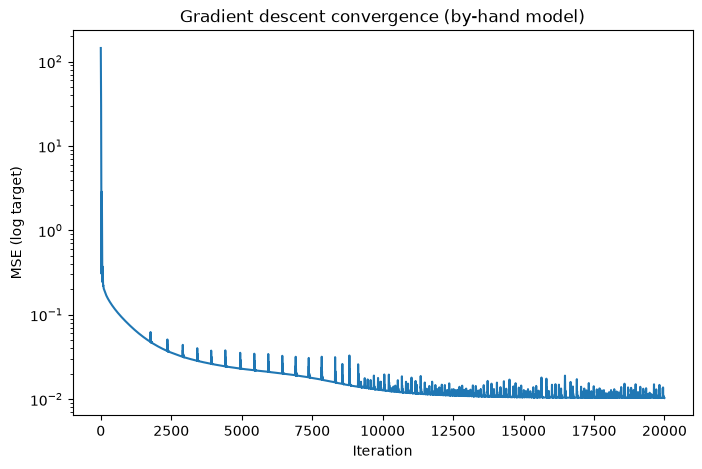

In [5]:
plt.plot(scratch.loss_history_)
plt.xlabel("Iteration")
plt.ylabel("MSE (log target)")
plt.title("Gradient descent convergence (by-hand model)")
plt.yscale("log")
plt.show()


The loss drops fast for the first ~2,000 iterations (the well-conditioned,
standardized numeric directions), then keeps inching down on a long, visibly
*noisy* tail (the near-flat, rare-category dummy directions) — that
oscillation, not just the slow descent, is the ill-conditioning described
above: Adam's fixed learning rate is a reasonable step size for the steep
directions but slightly overshoots on the near-flat ones every iteration.
Log-scale y-axis makes both regimes visible in one plot; a learning-rate
schedule that decays over time would smooth this tail out, at the cost of
one more hyperparameter to tune.


## 3. Train with scikit-learn: the closed-form solution

In [6]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

sklearn_pred_log = sklearn_model.predict(X_test)
sklearn_metrics = evaluate(y_test, sklearn_pred_log)
sklearn_metrics


{'log_r2': 0.890978206062927,
 'price_r2': 0.9011424112927369,
 'price_rmse': 23367.977390629232,
 'price_mae': 16582.665735660616}

## 4. Compare the two training methods

No loss curve for sklearn — `LinearRegression` solves for the coefficients
directly via least squares (SVD under the hood), there's no iterative descent
to plot. It's the reference answer gradient descent is trying to approximate.


In [7]:
comparison = pd.DataFrame(
    [
        {"model": "scratch (Adam)", **scratch_metrics},
        {"model": "sklearn (OLS)", **sklearn_metrics},
    ]
).set_index("model")
comparison


,log_r2,price_r2,price_rmse,price_mae
model,,,,
scratch (Adam),0.890756,0.900956,23390.046553,16614.953713
sklearn (OLS),0.890978,0.901142,23367.977391,16582.665736


### Do the two methods agree on *why*, not just *how well*?

Matching R² isn't the whole story — two models could reach similar accuracy
with different coefficients if features are correlated. Plotting one
coefficient vector against the other checks whether gradient descent actually
converged to (close to) the same solution sklearn solved for directly, or
just found a different, equally-good one.


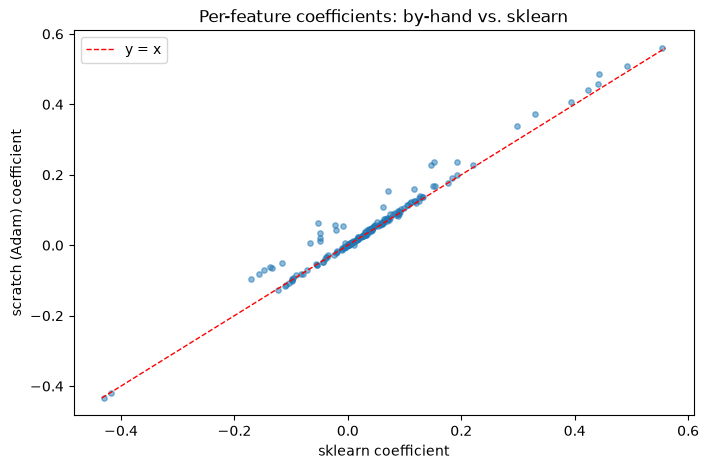

Correlation between coefficient vectors: 0.98199


In [8]:
plt.scatter(sklearn_model.coef_, scratch.coef_, alpha=0.5, s=15)
lims = [
    min(sklearn_model.coef_.min(), scratch.coef_.min()),
    max(sklearn_model.coef_.max(), scratch.coef_.max()),
]
plt.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="y = x")
plt.xlabel("sklearn coefficient")
plt.ylabel("scratch (Adam) coefficient")
plt.title("Per-feature coefficients: by-hand vs. sklearn")
plt.legend()
plt.show()

coef_corr = np.corrcoef(sklearn_model.coef_, scratch.coef_)[0, 1]
print(f"Correlation between coefficient vectors: {coef_corr:.5f}")


A near-perfect diagonal confirms gradient descent didn't just match sklearn's
*accuracy* by coincidence — it converged to essentially the same 175-dimensional
solution, feature by feature.


## 5. Package both models for serving

This is the exact step `scripts/train_scratch.py` and `scripts/train_sklearn.py`
perform after fitting: wrap the coefficients in a `HousePriceModel` — the
class that actually knows how to turn a raw house into a prediction (see
`serving_model.py`) — bundling in the scaler stats and feature order so the
saved file is self-describing.


In [9]:
def to_serving_model(coef, intercept, name, extra_meta):
    return HousePriceModel(
        coef=coef,
        intercept=intercept,
        feature_names=feature_names,
        scaler_mean=scaler.mean_,
        scaler_scale=scaler.scale_,
        numeric_feature_cols=NUMERIC_FEATURE_COLS,
        meta={"model_name": name, **extra_meta},
    )


scratch_serving = to_serving_model(
    scratch.coef_, scratch.intercept_, "scratch",
    {"training_method": "gradient descent (Adam, numpy)", "test_metrics": scratch_metrics},
)
sklearn_serving = to_serving_model(
    sklearn_model.coef_, sklearn_model.intercept_, "sklearn",
    {"training_method": "sklearn LinearRegression (closed-form OLS)", "test_metrics": sklearn_metrics},
)

MODELS_DIR.mkdir(exist_ok=True)
for name, model in [("scratch", scratch_serving), ("sklearn", sklearn_serving)]:
    model.save_pickle(MODELS_DIR / f"{name}_model.pkl")
    model.save_joblib(MODELS_DIR / f"{name}_model.joblib")
    model.save_raw_json(MODELS_DIR / f"{name}_model_raw.json")
    model.save_raw_npz(MODELS_DIR / f"{name}_model_raw.npz")

print(f"Wrote 8 model files to {MODELS_DIR}")


Wrote 8 model files to /opt/wecan/aiml_learning_gang_ws/AIML_Learning_Gang/ML-foundations/notebooks/house-prices-regression/sample-4/models


## 6. Follow one house through inference

Same steps `app/main.py` runs on every API request: encode the raw columns,
align to the frozen `feature_names` order, scale, then `coef @ x + intercept`.


In [10]:
raw = pd.read_csv("dataset/train.csv")
sample_house = raw.iloc[[7]].drop(columns=["SalePrice", "Id"])
actual_price = raw.iloc[7]["SalePrice"]

reloaded = HousePriceModel.load_raw_json(MODELS_DIR / "sklearn_model_raw.json")
log_pred = reloaded.predict_log(sample_house)[0]
price_pred = reloaded.predict_price(sample_house)[0]

print(f"log1p(SalePrice) prediction: {log_pred:.4f}")
print(f"Back-transformed (expm1):    ${price_pred:,.0f}")
print(f"Actual sale price:           ${actual_price:,.0f}")


log1p(SalePrice) prediction: 12.3314
Back-transformed (expm1):    $226,708
Actual sale price:           $200,000


`reloaded` was loaded from `sklearn_model_raw.json` — plain JSON, no sklearn
object, no `HousePriceModel` pickled inside it — yet it reproduces the same
prediction pipeline. Swap in `.load_pickle(...)` or `.load_joblib(...)` on the
`.pkl`/`.joblib` files this notebook just saved and you'll get the identical
number back; that equivalence across formats is what `app/main.py`'s
`/predict/{model}/{format}` endpoint and `streamlit_app.py`'s "compare all"
view both demonstrate live.


## Next steps

- **`README.md`** — the pickle vs. joblib vs. raw JSON/npz tradeoff table
  (version coupling, security, portability) referenced above.
- **`uv run uvicorn app.main:app --reload`** — serve the models this notebook
  just trained over HTTP.
- **`uv run streamlit run streamlit_app.py`** — a form UI on top of that API.
